In [1]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

In [7]:
warehouses_path = r'C:\Users\titas\Desktop\LP_Project\Warehouse Optimisation\data\warehouses.csv'
stores_path = r'C:\Users\titas\Desktop\LP_Project\Warehouse Optimisation\data\stores.csv'


In [9]:
df = pd.read_csv(warehouses_path)
df
df_stores = pd.read_csv(stores_path)
df_stores

,id,name,latitude,longitude,demand
0,S1,London,51.507446,-0.127765,1800
1,S2,Chelmsford,51.734533,0.473053,400
2,S3,Brighton,50.821463,-0.140056,500
3,S4,Bristol,51.443014,-2.581662,800
4,S5,Birmingham,52.494899,-1.851844,1300
5,S6,Leicester,52.636200,-1.133197,600
6,S7,Norwich,52.628558,1.292395,450
7,S8,Nottingham,52.953419,-1.149646,700
8,S9,Sheffield,53.380663,-1.470228,850
9,S10,Leeds,53.797418,-1.543794,1100


In [14]:
# convert long/lat to points
df_geo = gpd.GeoDataFrame(df, geometry = gpd.points_from_xy(df.longitude, df.latitude))
df_geo_stores = gpd.GeoDataFrame(df_stores, geometry = gpd.points_from_xy(df_stores.longitude, df_stores.latitude))
df_geo

,id,name,latitude,longitude,capacity,geometry
0,W1,Basildon Distribution Centre,51.588740,0.485961,5000,POINT (0.48596 51.58874)
1,W2,Birmingham Distribution Centre,52.514284,-1.880850,6000,POINT (-1.88085 52.51428)
2,W3,Leeds Distribution Centre,53.772075,-1.514109,4000,POINT (-1.51411 53.77208)


In [15]:
%pip install geodatasets
import geodatasets

# get built-in dataset
world_data = gpd.read_file(geodatasets.get_path('naturalearth.land'))
world_data

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,featurecla,scalerank,min_zoom,geometry
0,Land,1,1.0,"POLYGON ((-59.57209 -80.04018, -59.86585 -80.5..."
1,Land,1,1.0,"POLYGON ((-159.20818 -79.49706, -161.1276 -79...."
2,Land,1,0.0,"POLYGON ((-45.15476 -78.04707, -43.92083 -78.4..."
3,Land,1,1.0,"POLYGON ((-121.21151 -73.50099, -119.91885 -73..."
4,Land,1,1.0,"POLYGON ((-125.55957 -73.48135, -124.03188 -73..."
...,...,...,...,...
122,Land,1,1.0,"POLYGON ((51.13619 80.54728, 49.79368 80.41543..."
123,Land,0,0.0,"POLYGON ((99.93976 78.88094, 97.75794 78.7562,..."
124,Land,0,0.0,"POLYGON ((-87.02 79.66, -85.81435 79.3369, -87..."
125,Land,0,0.0,"POLYGON ((-68.5 83.10632, -65.82735 83.02801, ..."


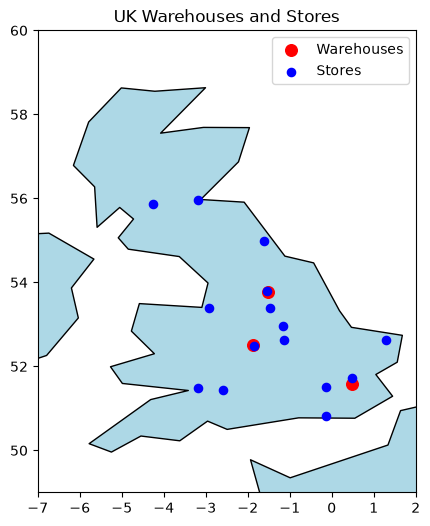

In [16]:
# plot the UK map with warehouses and stores
axis = world_data.plot(color='lightblue', edgecolor='black')
df_geo.plot(ax=axis, color='red', markersize=70, label='Warehouses')
df_geo_stores.plot(ax=axis, color='blue', markersize=35, label='Stores')

# Zoom the map view exclusively to the UK coordinates
axis.set_xlim(-7, 2)   # Longitude (West to East)
axis.set_ylim(49, 60)   # Latitude (South to North)

plt.title('UK Warehouses and Stores')
axis.legend()

fig = plt.gcf()
fig.set_size_inches(9,6)
fig.savefig('matplot.png', dpi = 200)
plt.show()

In [12]:
import plotly.express as px

f = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    hover_name="name",
    size="capacity",
    color_discrete_sequence=['red'],
    scope="europe",
    title="UK Warehouses and Stores",
    projection="natural earth",
    template="plotly_white"
 )

f.add_scattergeo(
    lat=df_stores["latitude"],
    lon=df_stores["longitude"],
    text=df_stores["name"],
    hovertemplate='<b>%{text}</b><br>demand=%{marker.size}<extra></extra>',
    marker=dict(size=df_stores["demand"], color='blue', sizemode='area', sizeref=8),
    name='Stores'
 )

f.update_geos(
    lonaxis_range=[-8, 2],
    lataxis_range=[49, 59],
    showcountries=True
 )

f